# Building Deep Neural Networks with Different Depths (10, 15, 20 Layers)

## Objective

The objective of this task is to design, implement, and evaluate Deep Neural Network (DNN) models with varying depths (10, 15, and 20 hidden layers) for binary image classification.

---

## Dataset Description

Refer to the provided folder structure containing image data for two classes:

- **Cars**
- **Bikes**

The dataset is organized as:



---

## Task Requirements

### 1. Data Preprocessing

- Load all RGB images from both **Cars** and **Bikes** folders.
- Resize each image to a fixed size (e.g., 128 × 128).
- Normalize pixel values to the range [0, 1].
- Flatten each image into a one-dimensional vector suitable for a fully connected neural network.
- Assign appropriate class labels:
  - Cars → 0
  - Bikes → 1
- Combine both classes into a single dataset.
- Shuffle the dataset randomly.
- Split the dataset into:
  - **80% Training Set**
  - **20% Testing Set**

In [3]:
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt

In [4]:
# DATA PREPROCESSING
def load_and_preprocess(car_dir, bike_dir, size=(128, 128)): # Resize to 128x128
    data = []
    labels = []
    
    # Assign labels: Cars-0, Bikes-1
    configs = [(car_dir, 0), (bike_dir, 1)]
    
    for folder, label in configs:
        for filename in os.listdir(folder):
            if filename.lower().endswith('.bmp'):
                # Load RGB images
                img = Image.open(os.path.join(folder, filename)).convert('RGB')
                img = img.resize(size)
                # Normalize to [0, 1] and flatten into 1D vector
                data.append(np.array(img).flatten() / 255.0) 
                labels.append(label)
    
    X = np.array(data).T # Shape: (features, m)
    Y = np.array(labels).reshape(1, -1)
    
    # Shuffle the dataset
    m = X.shape[1]
    permutation = np.random.permutation(m)
    X, Y = X[:, permutation], Y[:, permutation]
    
    # 80% Training, 20% Testing split
    split_idx = int(m * 0.8)
    return X[:, :split_idx], Y[:, :split_idx], X[:, split_idx:], Y[:, split_idx:]

---

### 2. Model Design

Design three Deep Neural Network architectures with different depths:

#### Model A: 10 Hidden Layers
- Input Layer
- 10 Fully Connected Hidden Layers
- Output Layer (1 neuron for binary classification)

#### Model B: 15 Hidden Layers
- Input Layer
- 15 Fully Connected Hidden Layers
- Output Layer (1 neuron for binary classification)

#### Model C: 20 Hidden Layers
- Input Layer
- 20 Fully Connected Hidden Layers
- Output Layer (1 neuron for binary classification)

---

### 3. Activation Functions

- Hidden Layers: ReLU
- Output Layer: Sigmoid (for binary classification)

In [6]:
# MODEL DESIGN & ACTIVATION FUNCTIONS
class DeepNeuralNetwork:
    def __init__(self, layer_dims):
        self.params = {}
        self.L = len(layer_dims) - 1 # Total layers
        for l in range(1, self.L + 1):
            # He Initialization for deep networks
            self.params[f'W{l}'] = np.random.randn(layer_dims[l], layer_dims[l-1]) * np.sqrt(2/layer_dims[l-1])
            self.params[f'b{l}'] = np.zeros((layer_dims[l], 1))

    def forward(self, X):
        caches = []
        A = X
        # Hidden Layers: ReLU
        for l in range(1, self.L):
            A_prev = A
            Z = np.dot(self.params[f'W{l}'], A_prev) + self.params[f'b{l}']
            A = np.maximum(0, Z)
            caches.append((A_prev, Z))
            
        # Output Layer: Sigmoid
        ZL = np.dot(self.params[f'W{self.L}'], A) + self.params[f'b{self.L}']
        AL = 1 / (1 + np.exp(-ZL))
        caches.append((A, ZL))
        return AL, caches

    def backward(self, Y, AL, caches):
        grads = {}
        m = Y.shape[1]
        
        # dZ for output layer
        dZ = AL - Y
        grads[f'dW{self.L}'] = (1/m) * np.dot(dZ, caches[-1][0].T)
        grads[f'db{self.L}'] = (1/m) * np.sum(dZ, axis=1, keepdims=True)
        
        # Backprop through hidden layers
        for l in reversed(range(1, self.L)):
            dA = np.dot(self.params[f'W{l+1}'].T, dZ)
            # ReLU derivative
            dZ = dA * (caches[l-1][1] > 0)
            grads[f'dW{l}'] = (1/m) * np.dot(dZ, caches[l-1][0].T)
            grads[f'db{l}'] = (1/m) * np.sum(dZ, axis=1, keepdims=True)
        return grads

    def update(self, grads, lr): # Optimization
        for l in range(1, self.L + 1):
            self.params[f'W{l}'] -= lr * grads[f'dW{l}']
            self.params[f'b{l}'] -= lr * grads[f'db{l}']

---

### 4. Training Process

The model must be trained using:

- Forward Propagation
- Backpropagation
- Optimization algorithm:
  - Gradient Descent (or Adam / RMSProp)

Monitor:
- Training Loss per Epoch

Train each model for a fixed number of epochs (e.g., 50 or 100).

---

### 5. Performance Evaluation

After training:

- Generate predictions on:
  - Training Data
  - Testing Data
- Compute:
  - Training Accuracy
  - Testing Accuracy

---

### 6. Visualization

Plot:

- **Loss vs Epochs Graph**

The graph must show how training loss decreases over epochs.


--- Training Model with 10 Hidden Layers ---
Epoch 0, Loss: 0.6914
Epoch 20, Loss: 0.6690
Epoch 40, Loss: 0.6692
Epoch 60, Loss: 0.7080
Epoch 80, Loss: 0.6609
Training Accuracy: 46.34%
Testing Accuracy: 49.68%


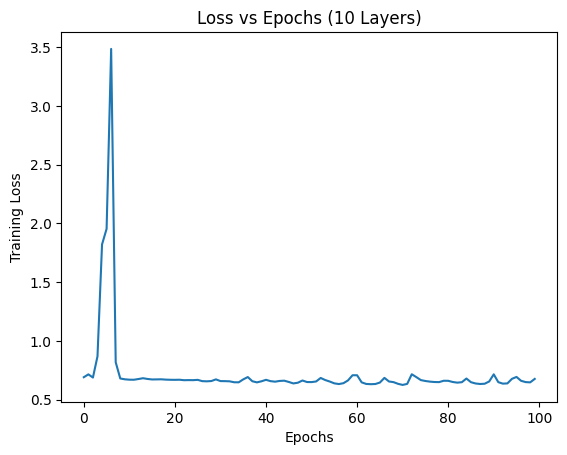


--- Training Model with 15 Hidden Layers ---
Epoch 0, Loss: 0.6815
Epoch 20, Loss: 0.6727
Epoch 40, Loss: 0.6789
Epoch 60, Loss: 0.6568
Epoch 80, Loss: 0.6839
Training Accuracy: 62.26%
Testing Accuracy: 64.33%


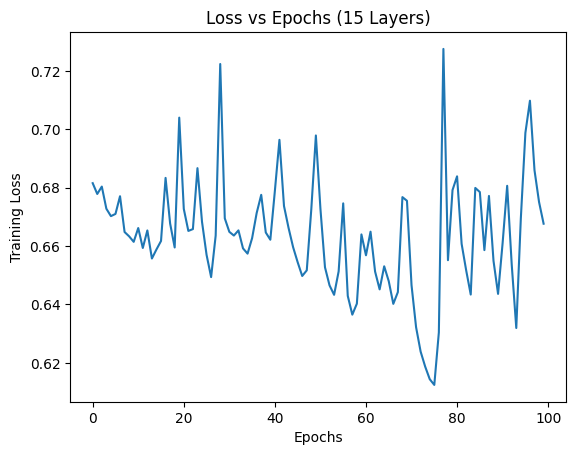


--- Training Model with 20 Hidden Layers ---
Epoch 0, Loss: 0.6989
Epoch 20, Loss: 0.6672
Epoch 40, Loss: 0.6585
Epoch 60, Loss: 0.6562
Epoch 80, Loss: 0.6578
Training Accuracy: 71.97%
Testing Accuracy: 73.89%


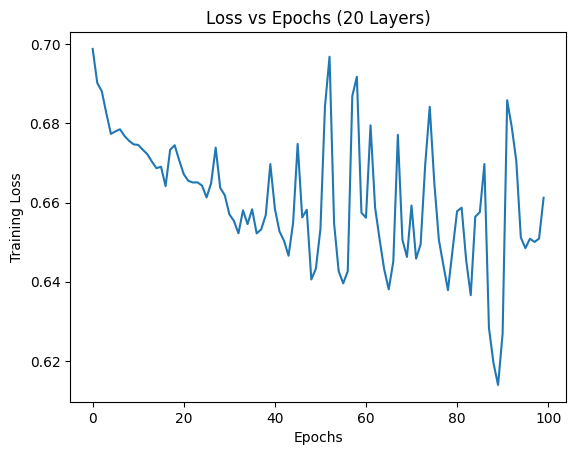

In [8]:
# TRAINING PROCESS
# Update these paths to your dataset location
X_train, Y_train, X_test, Y_test = load_and_preprocess('transport/cars', 'transport/bike')

layer_counts = [10, 15, 20] # Model A, B, and C 
learning_rate = 0.01
epochs = 100

for depth in layer_counts:
    print(f"\n--- Training Model with {depth} Hidden Layers ---")
    # layer_dims: Input (49152) -> Hidden Layers (64 each) -> Output (1)
    dims = [X_train.shape[0]] + [64] * depth + [1]
    model = DeepNeuralNetwork(dims)
    costs = []

    for i in range(epochs):
        AL, caches = model.forward(X_train)
        # Loss calculation
        cost = -np.mean(Y_train * np.log(AL + 1e-8) + (1 - Y_train) * np.log(1 - AL + 1e-8))
        costs.append(cost)
        
        grads = model.backward(Y_train, AL, caches)
        model.update(grads, learning_rate)
        
        if i % 20 == 0:
            print(f"Epoch {i}, Loss: {cost:.4f}")

    # PERFORMANCE EVALUATION
    def get_acc(X, Y, name):
        probs, _ = model.forward(X)
        preds = (probs > 0.5).astype(int)
        acc = np.mean(preds == Y) * 100
        print(f"{name} Accuracy: {acc:.2f}%")

    get_acc(X_train, Y_train, "Training")
    get_acc(X_test, Y_test, "Testing")

    # VISUALIZATION
    plt.plot(costs)
    plt.title(f"Loss vs Epochs ({depth} Layers)")
    plt.xlabel("Epochs")
    plt.ylabel("Training Loss")
    plt.show()

---

## Expected Output

For each model (10, 15, and 20 layers), report:

- Final Training Accuracy
- Final Testing Accuracy
- Loss vs Epoch Plot

---

## Comparative Analysis

Compare the performance of:

- 10-layer DNN
- 15-layer DNN
- 20-layer DNN

Discuss:

- Effect of network depth on accuracy
- Overfitting / Underfitting behavior
- Training stability
- Vanishing / Exploding gradient issues (if observed)